In [1]:
import pandas as pa
df = pa.read_csv("neut_test.csv")
df

,event_num,pid_nu,E_nu,is_CC,pid_lep,E_lepton,T_proton,num_pi0,E_pi0,num_cpi,T_cpi,E_nu_rec_true
0,0,14,0.5859,1,13,0.5067,0.0635,0,0.0000,0,0.0000,0.5702
1,1,14,0.3957,1,13,0.2562,0.0899,0,0.0000,0,0.0000,0.3461
2,2,14,0.3966,1,13,0.2156,0.1621,0,0.0000,0,0.0000,0.3776
3,3,14,0.5816,1,13,0.2044,0.0313,0,0.0000,1,0.1922,0.5674
4,4,14,0.8537,1,13,0.4092,0.4214,0,0.0000,0,0.0000,0.8306
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9995,14,0.7750,1,13,0.7165,0.0334,0,0.0000,0,0.0000,0.7498
9996,9996,14,0.7934,0,14,0.0000,0.0000,0,0.0000,0,0.0000,0.0000
9997,9997,14,0.7582,1,13,0.2398,0.5327,0,0.0000,0,0.0000,0.7725
9998,9998,14,0.7023,0,14,0.0000,0.1822,1,0.2026,0,0.0000,0.3848


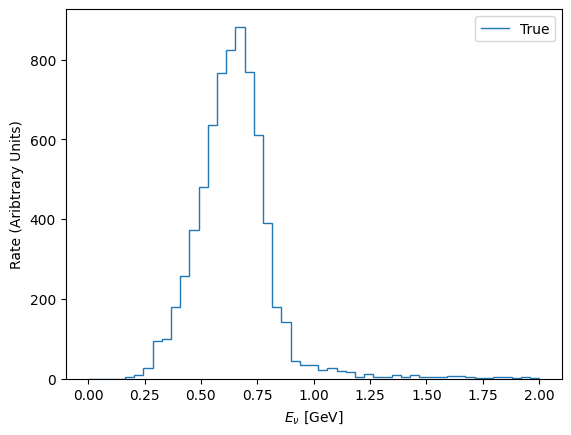

In [2]:
from proj_utils import hist1d, drawhist1d
import matplotlib.pyplot as plt
import numpy as np

dfcc = df[df["is_CC"] == 1].copy()

enu_hist = hist1d(data=dfcc["E_nu"], bins=np.linspace(0,2,50))
drawhist1d(hist=enu_hist, label="True")

plt.xlabel(r"$E_{\nu}$ [GeV]")
plt.ylabel("Rate (Aribtrary Units)")

plt.legend()
plt.show()

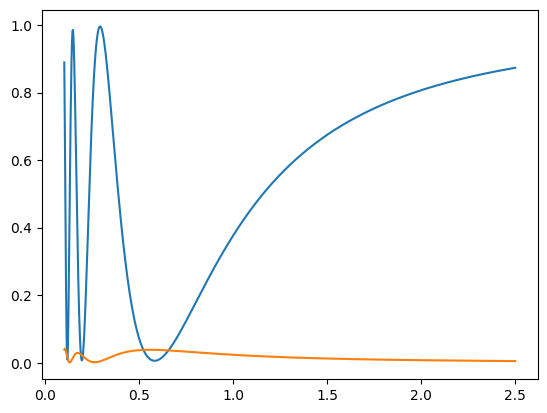

In [3]:
from proj_utils import Probability_Matter_LBL

osc_params = {
  "experimental_baseline_km": 295,
  "s12sq": 0.31,
  "s13sq": 0.02,
  "s23sq": 0.55,
  "delta": 0.7 * np.pi,
  "Dmsq21": 7.5e-5,
  "Dmsq31": 2.5e-3
}

E = np.linspace(0.1,2.5,1000)
probs = Probability_Matter_LBL(E, osc_params, osc_channels=["numu_survival", "nue_appearance"])

plt.plot(E, probs[0])
plt.plot(E, probs[1])
plt.show()

In [4]:
probs = Probability_Matter_LBL(dfcc["E_nu"], osc_params, osc_channels=["numu_survival", "nue_appearance"])

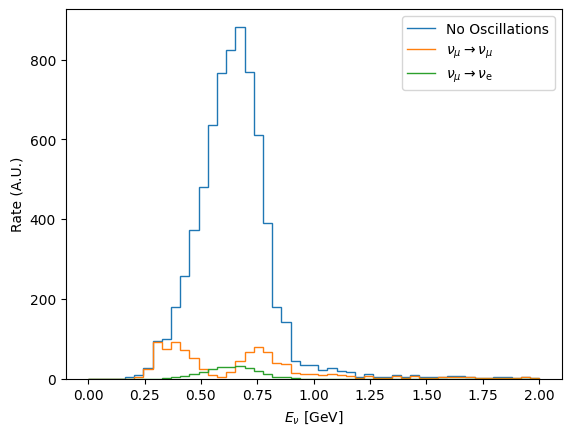

In [5]:
drawhist1d(data=dfcc["E_nu"], bins=np.linspace(0,2,50), label="No Oscillations")
drawhist1d(data=dfcc["E_nu"], bins=np.linspace(0,2,50), weights=probs[0], label=r"$\nu_\mu \rightarrow \nu_\mu$")
drawhist1d(data=dfcc["E_nu"], bins=np.linspace(0,2,50), weights=probs[1], label=r"$\nu_\mu \rightarrow \nu_\mathrm{e}$")
plt.xlabel(r"$E_{\nu}$ [GeV]")
plt.ylabel("Rate (A.U.)")
plt.legend()
plt.show()

In [6]:
from proj_utils import ReconstructedNeutrinoEnergy

reconstruction_params = {  "muon_energy_resolution": 0.02, # 2%
                           "electron_energy_resolution": 0.05, #
                           "proton_kinetic_energy_resolution": 0.1, #
                           "charged_pion_kinetic_energy_resolution": 0.1, #
                           "charged_pion_mass_visible_fraction": 0.75, #
                           "neutral_pion_energy_resolution": 0.1 #
                        }

dfcc["E_nu_rec_obs"] = ReconstructedNeutrinoEnergy(dfcc, reconstruction_params)
dfcc

,event_num,pid_nu,E_nu,is_CC,pid_lep,E_lepton,T_proton,num_pi0,E_pi0,num_cpi,T_cpi,E_nu_rec_true,E_nu_rec_obs
0,0,14,0.5859,1,13,0.5067,0.0635,0,0.0,0,0.0000,0.5702,0.550559
1,1,14,0.3957,1,13,0.2562,0.0899,0,0.0,0,0.0000,0.3461,0.360857
2,2,14,0.3966,1,13,0.2156,0.1621,0,0.0,0,0.0000,0.3776,0.406315
3,3,14,0.5816,1,13,0.2044,0.0313,0,0.0,1,0.1922,0.5674,0.526152
4,4,14,0.8537,1,13,0.4092,0.4214,0,0.0,0,0.0000,0.8306,0.894963
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9993,9993,14,0.6870,1,13,0.4343,0.2531,0,0.0,0,0.0000,0.6874,0.707484
9994,9994,14,0.8238,1,13,0.4182,0.3937,0,0.0,0,0.0000,0.8119,0.811172
9995,9995,14,0.7750,1,13,0.7165,0.0334,0,0.0,0,0.0000,0.7498,0.753375
9997,9997,14,0.7582,1,13,0.2398,0.5327,0,0.0,0,0.0000,0.7725,0.828479


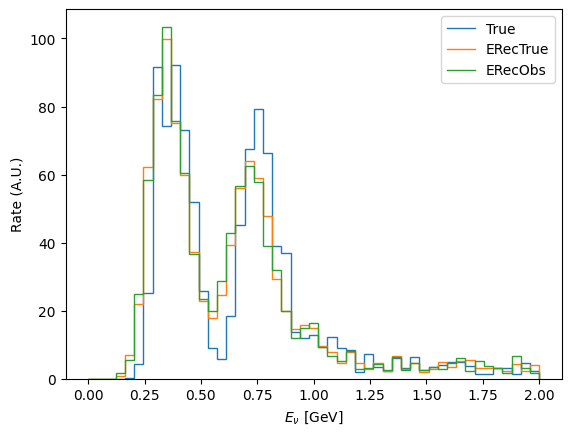

In [7]:
drawhist1d(data=dfcc["E_nu"], bins=np.linspace(0,2,50), weights=probs[0], label="True")
drawhist1d(data=dfcc["E_nu_rec_true"], bins=np.linspace(0,2,50), weights=probs[0], label="ERecTrue")
drawhist1d(data=dfcc["E_nu_rec_obs"], bins=np.linspace(0,2,50), weights=probs[0], label="ERecObs")
plt.xlabel(r"$E_{\nu}$ [GeV]")
plt.ylabel("Rate (A.U.)")
plt.legend()
plt.show()

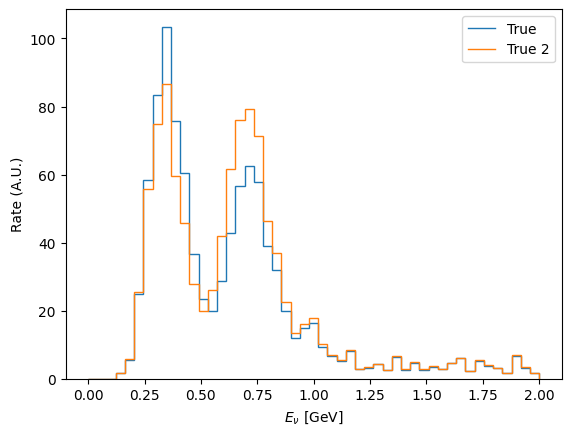

In [8]:
probs_ref = Probability_Matter_LBL(dfcc["E_nu"], osc_params, osc_channels=["numu_survival"])
href = hist1d(dfcc["E_nu_rec_obs"], np.linspace(0,2,50), weights=probs_ref[0])

osc_params_var = osc_params.copy()
osc_params_var["Dmsq31"] = 2.4e-3
probs_var = Probability_Matter_LBL(dfcc["E_nu"], osc_params_var, osc_channels=["numu_survival"])
hobs = hist1d(dfcc["E_nu_rec_obs"], np.linspace(0,2,50), weights=probs_var[0])

drawhist1d(hist=href, label="True")
drawhist1d(hist=hobs, label="True 2")

plt.xlabel(r"$E_{\nu}$ [GeV]")
plt.ylabel("Rate (A.U.)")
plt.legend()

plt.show()

In [9]:
from proj_utils import Poisson_N2LLH

def N2LLH(data_hist, simevs, osc_params):
    probs_varied = Probability_Matter_LBL(simevs["E_nu"], osc_params, osc_channels=["numu_survival"])
    predicted_hist = hist1d(dfcc["E_nu_rec_obs"], np.linspace(0,2,50), weights=probs_varied[0])
    
    return Poisson_N2LLH(data_hist, predicted_hist)

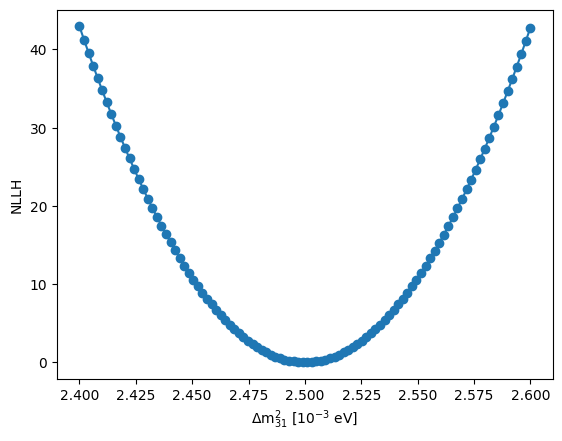

In [15]:
dm31s = np.linspace(2.4,2.6,100)

lhoods = []
for v in dm31s:
    var_osc_params = osc_params.copy()
    var_osc_params["Dmsq31"] = v * 1E-3
    lhoods.append(N2LLH(href, dfcc, var_osc_params))

# convert it to a numpy array
lhoods = np.array(lhoods)

plt.plot(dm31s,lhoods,marker="o")
plt.xlabel(r"$\Delta\mathrm{m}_{31}^{2}$ [$10^{-3}$ eV]")
plt.ylabel("NLLH")
plt.show()

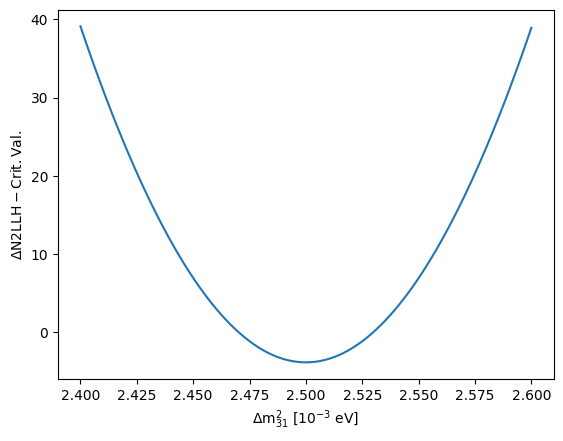

In [16]:
from scipy.interpolate import CubicSpline
cv = 3.85
delta_N2LLH = lhoods.copy() - np.min(lhoods)
INLLH = CubicSpline(dm31s, delta_N2LLH - cv)

plt.plot(dm31s,[INLLH(x) for x in dm31s])
plt.xlabel(r"$\Delta\mathrm{m}_{31}^{2}$ [$10^{-3}$ eV]")
plt.ylabel(r"$\Delta \mathrm{N2LLH} - \mathrm{Crit. Val.}$")
plt.show()

In [18]:
from scipy.optimize import newton

lower_bound = newton(INLLH, 2.41)
upper_bound = newton(INLLH, 2.59)
print(f"90% interval: DeltaMsq23 = [{lower_bound:.3f}, {upper_bound:.3f}] 10^-3 eV")

90% interval: DeltaMsq23 = [2.470, 2.530] 10^-3 eV
